# Lecture 18 - Correlation Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.style.use('fivethirtyeight')

%matplotlib inline


### Lecture Outline

- **Guessing the Future** – using data to anticipate outcomes  
- **Prediction & Trend** – identifying and modeling trends  
- **Association** – finding relationships between variables  
    - **Positive & Negative Association** – direction of relationships  
- **Correlation Coefficient** – measuring relationship strength  


#### Scatter Plot Function to be used in the Demo

In [ ]:
def r_scatter(r):
    plt.figure(figsize=(5,5))
    "Generate a scatter plot with a correlation approximately r"
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    plt.scatter(x, y, color='darkblue', s=20)
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)

## Guessing the Future 

- Based on incomplete information.  
- One way of making predictions:  
    - To predict an outcome for an individual,  
    - find others who are like that individual  
    - and whose outcomes you know.  
    - Use those outcomes as the basis of your prediction.


#### Demo1: Family Height-- Correlation Analysis

In [ ]:
families = pd.read_csv('data/family_heights.csv')
families.head(5)

In [ ]:
parent_avgs = ...
heights = pd.DataFrame({'Parent Average': parent_avgs, 
                        'Child': families['child']})


<details>
<summary>Click to show solution</summary>

<pre>

parent_avgs = (families["father"] + families["mother"])/2

</pre>
</details>


In [ ]:
heights.plot.scatter(...)


<details>
<summary>Click to show solution</summary>

<pre>

heights.plot.scatter(x='Parent Average', y='Child')

</pre>
</details>



#### To-do: Let's say we are interested in predicting the height of a child given the average parent's height is 68 inches. 

- We can examine the data points near a parent's average height of 68 inches. 

In [ ]:
nearby = heights[...]
nearby_mean = nearby['Child'].mean()
nearby_mean


<details>
<summary>Click to show solution</summary>

<pre>

nearby = heights[(heights['Parent Average'] >= 67.5) & (heights['Parent Average'] < 68.5)]

</pre>
</details>


In [ ]:
heights.plot.scatter(x='Parent Average', y='Child')
plt.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plt.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plt.scatter(68, nearby_mean, color='magenta', s=50);

### Predict Child Height

- Using this idea, we can create a function that will predict the height of a child given the parent's average height. 

In [ ]:
def predict_child(h):
    """Predict the height of a child whose parents have a parent average 
    height of p_avg.
    
    The prediction is the average height of the children whose parent average 
    height is in the range p_avg plus or minus 0.5.
    """
    nearby = heights[(heights['Parent Average'] >= h-1/2) & (heights['Parent Average'] < h+1/2)]
    return nearby['Child'].mean()

**Now we can create a new DataFrame that has the predicted height for each parents / child combination.** 

In [ ]:
heights_with_predictions = heights.copy()
heights_with_predictions['Prediction'] = (
    heights.apply(lambda x: predict_child(x['Parent Average']), axis=1))
heights_with_predictions.head(5)

In [ ]:
plt.scatter(heights_with_predictions['Parent Average'], 
            heights_with_predictions['Child'], 
            label='Child')
plt.scatter(heights_with_predictions['Parent Average'], 
            heights_with_predictions['Prediction'], 
            label='Prediction')

plt.xlabel('Parent Average')
plt.ylabel('Child')
plt.title('Scatter Plot of Parent Average vs. Child Height')

# Add a legend
plt.legend()

# Show the plot
plt.show()


*Back to Slides*

## Association

Association describes how two **numerical variables** are related to each other.

- **Trend** – overall direction of data points  
- **Positive Association** – as one variable increases, the other increases
    - Example: Height and weight — taller people often weigh more.
- **Negative Association** – as one variable increases, the other decreases
    - Example: Speed and travel time — higher speed usually means less travel time.   
- **Pattern** – any discernible “shape” in the scatter  
  - **Linear** – follows a straight-line pattern  
  - **Non-linear** – curved or complex relationship


### Demo2: Vehicle Data- Association

In [ ]:
hybrid = pd.read_csv('data/hybrid.csv')
hybrid.head(5)

In [ ]:
hybrid.sort_values('msrp', ascending = False)

#### Let's examine the relationship between several numeric variables.

In [ ]:
hybrid.plot.scatter(x='mpg', y='msrp');

In [ ]:
hybrid.plot.scatter(x='acceleration', y='msrp');

#### We can look solely at SUVs. 

In [ ]:
suv = hybrid[hybrid['class'] == 'SUV']
suv.shape

In [ ]:
suv.plot.scatter(x='acceleration', y='msrp');

In [ ]:
suv.plot.scatter(x='mpg', y='msrp');

*Back to Slides*

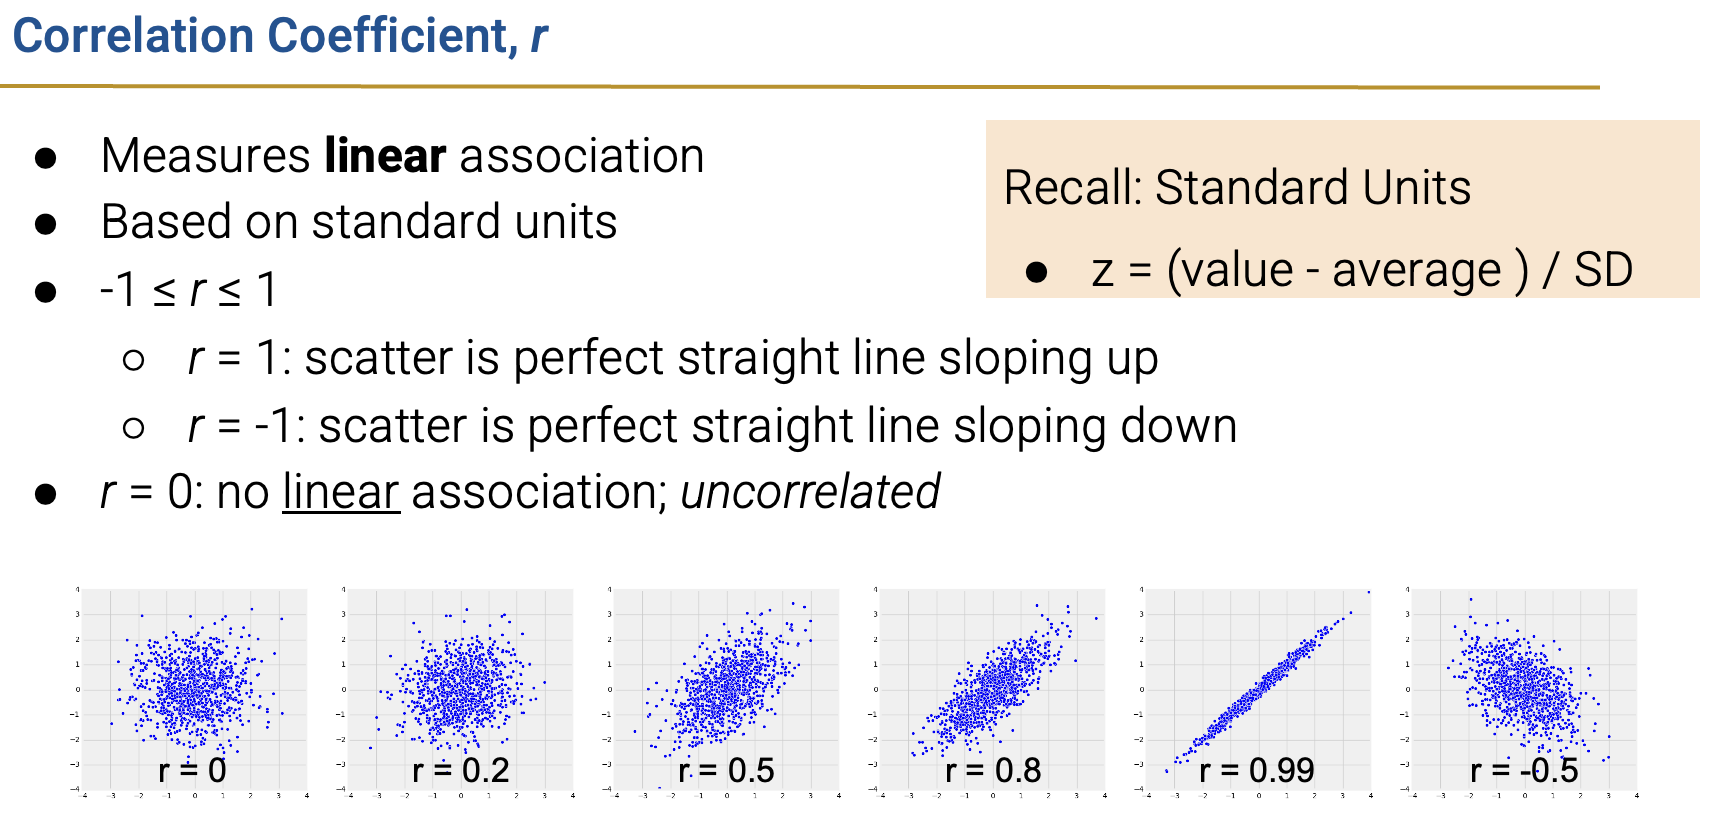

In [ ]:
def standard_units(x):
    "Convert any array of numbers to standard units."
    return (x - np.average(x)) / np.std(x)

In [ ]:
plt.scatter(standard_units(suv['mpg']), standard_units(suv['msrp']))
plt.xlim(-3, 3)
plt.xlim(-3, 3)
plt.xlabel('mpg (standard units)')
plt.ylabel('msrp (standard units)');

In [ ]:
suv.plot.scatter(x='acceleration', y='msrp');

In [ ]:
plt.scatter(standard_units(suv['acceleration']), 
            standard_units(suv['msrp']))
plt.xlim(-3, 3)
plt.xlim(-3, 3)
plt.xlabel('acceleration (standard units)')
plt.ylabel('msrp (standard units)');

## Correlation 


In [ ]:
r_scatter(-1)

In [ ]:
x = np.arange(1, 7, 1)
y = np.array([2, 3, 1, 5, 2, 7])

In [ ]:
plt.scatter(x, y, s=30, color='red')

In [ ]:
plt.scatter(standard_units(x), standard_units(y), s=30, color='red')

In [ ]:
df = pd.DataFrame({'x': x, 'y': y, 
                   'x (standard units)': standard_units(x), 
                   'y (standard units)': standard_units(y), 
                   'product of standard units':  standard_units(x)*standard_units(y)})
df

*Back to Slides*

### Here, we introduced the correlation coefficient: 

\begin{align}
r 
& = \text{Mean}\left(\text{StandardUnits}(x) *  \text{StandardUnits}(y)\right)\\
& = \frac{1}{n} \sum_{i=1}^n \text{StandardUnits}(x_i) *  \text{StandardUnits}(y_i)\\
& = \frac{1}{n}\sum_{i=1}^n \left( \frac{x_i - \text{Mean}(x)}{\text{Stdev}(x)} \right) * \left( \frac{y_i - \text{Mean}(y)}{\text{Stdev}(y)} \right) \\
\end{align}

In [ ]:
# r is the average of the products of the standard units 
r = np.average(df.iloc[:,2] * df.iloc[:,3])
r

#### Let's define a correlation function

In [ ]:
def correlation(df, x, y):
    """df is a DataFrame; x and y are column labels"""
    x_in_standard_units = standard_units(df[x])
    y_in_standard_units = standard_units(df[y])
    return np.average(x_in_standard_units * y_in_standard_units)

In [ ]:
correlation(df, 'x', 'y')

In [ ]:
# Built-in pandas function 

df.iloc[:,0:2].corr()

### Correlation Examples 

In [ ]:
suv.plot.scatter(x='mpg', y='msrp');

In [ ]:
correlation(suv, 'mpg', 'msrp')

In [ ]:
suv.plot.scatter(x='acceleration', y='msrp');

In [ ]:
correlation(suv, 'acceleration', 'msrp')

### Switching Axis and Observe Correlation

In [ ]:
correlation(df, 'x', 'y')

In [ ]:
df.plot.scatter(x='x', y='y', s=30, color='red');

In [ ]:
df.plot.scatter(x='y', y='x', s=30, color='blue');

In [ ]:
correlation(df, 'y', 'x')

*Back to Slides*

## Caution on Intrepreting Correlation 

- **False conclusions of causation** 
- **Nonlinearity** 
- **Outliers** 
- **Ecological correlations** 


### False Conclusions of Causation

A correlation between two variables does **not** mean one causes the other.

**Example:**  
- When people use more umbrellas, more rain is recorded — but using umbrellas does **not cause** rain!
- Both variables rise together (positive correlation), but the true cause is the weather, not the umbrellas.

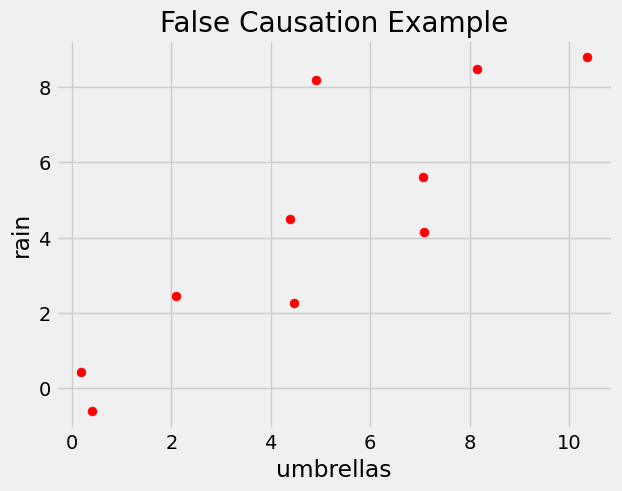

In [120]:
# Example
x = np.arange(0, 10)
rain = x + np.random.normal(0, 1, 10)     # rain increases
umbrellas = x + np.random.normal(0, 1, 10)  # umbrella use increases
df = pd.DataFrame({'umbrellas': umbrellas, 'rain': rain})
df.plot.scatter('umbrellas', 'rain', color='r', s=40, title='False Causation Example');

### Nonlinearity 

In [ ]:
new_x = np.arange(-4, 4.1, 0.5)
nonlinear = pd.DataFrame({'newx': new_x, 'y': new_x**2})
nonlinear.plot.scatter('newx', 'y', s=30, color='r');

In [ ]:
correlation(nonlinear, 'newx', 'y')

### Outliers 

In [ ]:
line = pd.DataFrame({'x': np.array([1, 2, 3, 4]), 
                     'y': np.array([1, 2, 3, 4])})
line.plot.scatter(x='x', y='y', s=30, color='r');

In [ ]:
correlation(line, 'x', 'y')

In [ ]:
outlier = pd.DataFrame({'x': np.array([1, 2, 3, 4, 5]), 
                        'y': np.array([1, 2, 3, 4, 0])})
outlier.plot.scatter(x='x', y='y', s=30, color='r');

In [ ]:
correlation(outlier, 'x', 'y')

### Ecological Correlations 

In [ ]:
sats = pd.read_csv('data/sat_scores.csv')
sats.sort_values('State', inplace=True)
sats.head(10)

In [ ]:
sats.plot.scatter(x='Critical Reading', y='Math');

In [ ]:
correlation(sats, 'Critical Reading', 'Math')

In [ ]:
def rate_code(x):
    if x <= 25:
        return 'low'
    elif x <= 50:
        return 'low-moderate'
    elif x <= 75:
        return 'moderate_high'
    else:
        return 'high'

In [ ]:
rate_codes = sats.apply(lambda x: rate_code(x['Participation Rate']), axis=1)

In [ ]:
sats['Rate Code'] = rate_codes
sats.head(10)

In [ ]:
sns.scatterplot(data=sats, x="Critical Reading", y="Math", hue="Rate Code");

In [ ]:
sats[sats['Rate Code'] == 'low']

In [ ]:
sats[sats['Rate Code'] == 'high']

# See You Next Lecture!